### Dependencies

Install the Python packages used for numerical computation and visualization.


In [1]:
# Install dependencies (run once)
# !pip install -q numpy matplotlib plotly
# !pip install tqdm

### Imports

We use NumPy for vectorized field evaluation and Matplotlib/Plotly for plotting.


In [2]:
# Imports
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import plotly.graph_objects as go

try:
    from tqdm.auto import tqdm
except Exception:
    class _NoTqdm:
        def __init__(self, iterable=None, total=None, desc=None, **kwargs):
            self.iterable = iterable
            self.total = total or 0
            self.n = 0
            self.desc = desc

        def __iter__(self):
            if self.iterable is None:
                return iter(())
            return iter(self.iterable)

        def update(self, n=1):
            self.n += n

        def __enter__(self):
            return self

        def __exit__(self, exc_type, exc, tb):
            return False

    def tqdm(iterable=None, **kwargs):
        return _NoTqdm(iterable=iterable, **kwargs)


def save_animation_with_progress(anim, path, fps=18, desc="Saving animation"):
    total = getattr(anim, "save_count", None)
    if total in (None, 0):
        total = globals().get("N_FRAMES")
    if total in (None, 0):
        total = 0
    with tqdm(total=total, desc=desc) as pbar:
        def _progress(i, n):
            if n:
                pbar.total = n
            pbar.update(i + 1 - pbar.n)
        anim.save(path, writer="pillow", fps=fps, progress_callback=_progress)

mpl.rcParams["animation.embed_limit"] = 60


/home/ubuntu/projects/simulations/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Output directory

All plots and animations are saved into `results/` with descriptive filenames.


In [3]:
# Output directory for saved figures and animations
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

def result_path(name: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in name)
    return str(RESULTS_DIR / safe)


# Electromagnetic Antenna Simulation (Phasor, Modular)

This notebook builds a compact but more usable EM field simulation around a **finite-length dipole**
modeled as a line of small Hertzian dipoles with a sinusoidal current distribution.
It produces near-field structure, far-field radiation patterns, and time-domain animations
reconstructed from phasor fields.

The structure is intentionally modular: you can swap the antenna model, change the
current distribution, or replace the analytic line-dipole superposition with a numerical solver.

### Simulation steps (numerical approach)

- Define a 3D Cartesian grid and antenna geometry from user parameters (frequency, current, length, wire shape).
- Compute phasor-domain electric and magnetic fields by superposing analytic Hertzian dipole fields along the antenna (line-dipole model). This is an analytic superposition method, not FEM/FDTD.
- Optionally add a toy internal-field model inside the conductor, then combine internal + external fields with a hard mask.
- Derive secondary quantities (field magnitude, Poynting vector) on the grid.
- Convert phasor fields to time-domain snapshots via $\Re\{\mathbf{E} e^{j\omega t}\}$ for animations.
- Visualize slices and 3D volumes with consistent scaling and vector normalization so geometry and magnitudes stay comparable across parameter changes.


### Simulation configuration

We define the computational domain and antenna parameters. The wavelength is
$\lambda = c_0 / f$ and the domain size is set in multiples of $\lambda$ to
capture several wavefronts while keeping the grid size manageable.


In [4]:
# Configuration (edit here)
import numpy as np

# Grid
NX, NY, NZ = 151, 151, 151  # grid points along x, y, z

# Antenna
ANTENNA_TYPE = "wire"  # "dipole" or "wire"

ANTENNA_LENGTH = 1  # meters (total length)
ANTENNA_RADIUS = 0.01  # meters (wire radius)
CURRENT_AMP = 1.0  # Amps (phasor magnitude)
FREQUENCY = 300e6  # Hz

# Derived scale (keep waves visible and computation reasonable)
C0 = 299_792_458.0  # m/s
LAMBDA = C0 / FREQUENCY  # meters
EXTENT_M = 1.5 * LAMBDA  # half-size of simulation box (meters)

# Wire antenna options (used when ANTENNA_TYPE == "wire")
WIRE_SHAPE = "v_dipole"  # "loop", "rect_loop", "v_dipole", "straight", "custom"
WIRE_PLANE = "xz"  # "xy", "xz", "yz"
WIRE_AXIS = "z"  # straight wire axis
WIRE_CURRENT_PROFILE = "sinusoidal"  # "uniform" or "sinusoidal"
WIRE_N_POINTS = 181  # polyline points along the wire path
LOOP_RADIUS = 0.2  # meters
RECT_WIDTH = 0.05  # meters
RECT_HEIGHT = 0.5  # meters
V_ANGLE_DEG = 50.0  # degrees (total angle)
# WIRE_POINTS = None  # custom polyline, shape (N, 3)
WIRE_POINTS = np.array([[0.0, -0.1, -0.1], [0.0, 0.1, -0.1], [0.0, 0.1, 0.1], [0.0, -0.1, 0.1]])  # custom polyline, shape (N, 3)

# Field model
MODEL = "line"  # "line" or "point" (dipole only)
N_SEGMENTS = 151  # line-dipole segments for dipole superposition

# Time samples for animation
N_FRAMES = 30  # animation frames per period
T_MAX = 1.0 / FREQUENCY  # one period (s)

# Visualization sampling
QUIVER_STEP = 5  # vector downsampling on 2D slices
QUIVER_3D_LENGTH = 0.35  # 3D quiver arrow length
SLICE_AXIS = "y"  # used only where a single slice is needed


# 3D camera controls
CAMERA_ELEV = 30  # degrees
CAMERA_AZIM = -55  # degrees
CAMERA_DIST = 9  # matplotlib 3D camera distance

np.set_printoptions(precision=3, suppress=True)

# Results subfolder per antenna configuration

def _slugify(text: str) -> str:
    return "".join(c if c.isalnum() or c in "-_." else "_" for c in text)


def _format_val(val: float) -> str:
    return f"{val:.3g}"


def _antenna_run_id() -> str:
    parts = [ANTENNA_TYPE]
    if ANTENNA_TYPE == "dipole":
        parts += [
            f"L{_format_val(ANTENNA_LENGTH)}m",
            f"r{_format_val(ANTENNA_RADIUS)}m",
            f"f{_format_val(FREQUENCY / 1e6)}MHz",
            f"model{MODEL}",
            f"seg{N_SEGMENTS}",
        ]
    else:
        parts += [
            WIRE_SHAPE,
            f"f{_format_val(FREQUENCY / 1e6)}MHz",
            f"n{WIRE_N_POINTS}",
            f"plane{WIRE_PLANE}",
        ]
        if WIRE_SHAPE == "loop":
            parts.append(f"R{_format_val(LOOP_RADIUS)}m")
        elif WIRE_SHAPE == "rect_loop":
            parts.append(f"W{_format_val(RECT_WIDTH)}m")
            parts.append(f"H{_format_val(RECT_HEIGHT)}m")
        elif WIRE_SHAPE == "v_dipole":
            parts.append(f"angle{_format_val(V_ANGLE_DEG)}deg")
            parts.append(f"L{_format_val(ANTENNA_LENGTH)}m")
        elif WIRE_SHAPE == "straight":
            parts.append(f"axis{WIRE_AXIS}")
            parts.append(f"L{_format_val(ANTENNA_LENGTH)}m")
        elif WIRE_SHAPE == "custom":
            parts.append("custom")
    return _slugify("_".join(parts))


RESULTS_RUN_DIR = RESULTS_DIR / _antenna_run_id()
RESULTS_RUN_DIR.mkdir(parents=True, exist_ok=True)


def result_path(name: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in name)
    return str(RESULTS_RUN_DIR / safe)



### Antenna configuration tips

- Use `ANTENNA_TYPE = "dipole"` for the analytic dipole or `"wire"` for custom shapes.
- For wire antennas, choose a `WIRE_SHAPE` and plane/axis, or provide `WIRE_POINTS`.
- `WIRE_CURRENT_PROFILE = "sinusoidal"` mimics a fed wire; `"uniform"` is best for loops.


## Mathematical model

We use time-harmonic (phasor) fields with time dependence e^(i w t).
Maxwell's equations in free space are:

curl E = -i w mu0 H
curl H =  i w eps0 E + J
div E = 0
div H = 0

A finite-length dipole is modeled as a line of small Hertzian dipoles along z,
each carrying a sinusoidal current distribution:

I(z) = I0 sin(k (L/2 - |z|))

The total field is the superposition of the fields from all segments.
This improves near-field structure and yields a realistic radiation pattern
while keeping the simulation lightweight and extensible.

For time-domain visualization we reconstruct:

Re{E(r) e^(i w t)}

on a slice of the simulation volume.

### Field computation setup

We compute phasor fields with time dependence $e^{j\omega t}$ using a line-dipole
superposition for the dipole or a polyline thin-wire model for custom antennas.


In [5]:
from emsim.grid import create_grid
from emsim.antenna import (
    DipoleAntenna,
    WireAntenna,
    make_straight_wire,
    make_circular_loop,
    make_rectangular_loop,
    make_v_dipole,
    resample_polyline,
)
from emsim.fields import (
    dipole_fields,
    line_dipole_fields,
    wire_antenna_fields,
    internal_antenna_fields,
    empty_internal_fields,
    combine_fields,
)
from emsim.viz import field_magnitude, poynting_vector, take_slice

X, Y, Z, dx, dy, dz = create_grid(NX, NY, NZ, EXTENT_M)
antenna_path = None

if ANTENNA_TYPE == "dipole":
    antenna = DipoleAntenna(
        length=ANTENNA_LENGTH,
        radius=ANTENNA_RADIUS,
        current_amp=CURRENT_AMP,
        frequency=FREQUENCY,
    )

    if MODEL == "line":
        E_ext = line_dipole_fields(antenna, X, Y, Z, n_segments=N_SEGMENTS)
    else:
        E_ext = dipole_fields(antenna, X, Y, Z)

    # Internal antenna fields (toy model, replace as needed)
    iEx, iEy, iEz, iHx, iHy, iHz, inside_mask = internal_antenna_fields(antenna, X, Y, Z)

    # Combined fields: external everywhere, internal inside antenna volume
    E_combined = combine_fields(E_ext, (iEx, iEy, iEz, iHx, iHy, iHz), inside_mask)
else:
    if WIRE_SHAPE == "custom":
        if WIRE_POINTS is None:
            raise ValueError("WIRE_POINTS must be set when WIRE_SHAPE == 'custom'")
        path = resample_polyline(WIRE_POINTS, WIRE_N_POINTS)
    elif WIRE_SHAPE == "loop":
        path = make_circular_loop(LOOP_RADIUS, n_points=WIRE_N_POINTS, plane=WIRE_PLANE)
    elif WIRE_SHAPE == "rect_loop":
        path = make_rectangular_loop(RECT_WIDTH, RECT_HEIGHT, n_points=WIRE_N_POINTS, plane=WIRE_PLANE)
    elif WIRE_SHAPE == "v_dipole":
        path = make_v_dipole(ANTENNA_LENGTH, V_ANGLE_DEG, n_points=WIRE_N_POINTS, plane=WIRE_PLANE)
    elif WIRE_SHAPE == "straight":
        path = make_straight_wire(ANTENNA_LENGTH, n_points=WIRE_N_POINTS, axis=WIRE_AXIS)
    else:
        raise ValueError("WIRE_SHAPE must be one of: loop, rect_loop, v_dipole, straight, custom")

    antenna = WireAntenna(
        path=path,
        radius=ANTENNA_RADIUS,
        current_amp=CURRENT_AMP,
        frequency=FREQUENCY,
        current_profile=WIRE_CURRENT_PROFILE,
    )
    E_ext = wire_antenna_fields(antenna, X, Y, Z)
    iEx, iEy, iEz, iHx, iHy, iHz, inside_mask = empty_internal_fields(X, Y, Z)
    E_combined = E_ext
    antenna_path = antenna.path

Ex, Ey, Ez, Hx, Hy, Hz = E_combined
E_mag = field_magnitude(Ex, Ey, Ez)
H_mag = field_magnitude(Hx, Hy, Hz)
Sx, Sy, Sz = poynting_vector(Ex, Ey, Ez, Hx, Hy, Hz)


def plot_antenna_geometry(ax):
    if antenna_path is not None:
        ax.plot(antenna_path[:, 0], antenna_path[:, 1], antenna_path[:, 2],
                color="silver", linewidth=2)
        return

    theta = np.linspace(0, 2.0 * np.pi, 30)
    z = np.linspace(-ANTENNA_LENGTH / 2.0, ANTENNA_LENGTH / 2.0, 30)
    theta_grid, z_grid = np.meshgrid(theta, z)
    x_cyl = ANTENNA_RADIUS * np.cos(theta_grid)
    y_cyl = ANTENNA_RADIUS * np.sin(theta_grid)
    ax.plot_surface(x_cyl, y_cyl, z_grid, alpha=0.35, color="dimgray")


Wire segments:   0%|          | 0/360 [00:00<?, ?it/s]

Wire segments:   0%|          | 1/360 [00:00<04:59,  1.20it/s]

Wire segments:   1%|          | 2/360 [00:01<03:43,  1.60it/s]

Wire segments:   1%|          | 3/360 [00:01<02:56,  2.02it/s]

Wire segments:   1%|          | 4/360 [00:01<02:33,  2.33it/s]

...

Wire segments:  99%|█████████▉| 356/360 [02:23<00:01,  2.77it/s]

Wire segments:  99%|█████████▉| 357/360 [02:23<00:01,  2.81it/s]

Wire segments:  99%|█████████▉| 358/360 [02:24<00:00,  2.86it/s]

Wire segments: 100%|█████████▉| 359/360 [02:24<00:00,  2.90it/s]

Wire segments: 100%|██████████| 360/360 [02:24<00:00,  2.90it/s]

### Shared slice helpers

Helper functions for extracting 2D planes consistently across plots and animations.


In [6]:
# Shared slice helpers
def _slice_components(axis, Fx, Fy, Fz, index):
    if axis == "x":
        xs = Y[index, :, :]
        ys = Z[index, :, :]
        u = Fy[index, :, :]
        v = Fz[index, :, :]
        xlabel, ylabel = "y (m)", "z (m)"
    elif axis == "y":
        xs = X[:, index, :]
        ys = Z[:, index, :]
        u = Fx[:, index, :]
        v = Fz[:, index, :]
        xlabel, ylabel = "x (m)", "z (m)"
    else:
        xs = X[:, :, index]
        ys = Y[:, :, index]
        u = Fx[:, :, index]
        v = Fy[:, :, index]
        xlabel, ylabel = "x (m)", "y (m)"
    return xs, ys, u, v, xlabel, ylabel

def _normalize_uv(u, v):
    mag = np.sqrt(u**2 + v**2) + 1e-12
    return u / mag, v / mag

def _scale_vec3(u, v, w, mask=None, pct=95, max_norm=1.0):
    mag = np.sqrt(u**2 + v**2 + w**2)
    if mask is not None:
        mag = np.where(mask, np.nan, mag)
    valid = mag[np.isfinite(mag)]
    if valid.size:
        scale = np.nanpercentile(valid, pct)
    else:
        scale = 1.0
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    u_s = u / scale
    v_s = v / scale
    w_s = w / scale
    mag_s = np.sqrt(u_s**2 + v_s**2 + w_s**2) + 1e-12
    cap = np.minimum(1.0, max_norm / mag_s)
    return u_s * cap, v_s * cap, w_s * cap


def _apply_vec_scale(u, v, w, scale, max_norm=1.0):
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    u_s = u / scale
    v_s = v / scale
    w_s = w / scale
    mag_s = np.sqrt(u_s**2 + v_s**2 + w_s**2) + 1e-12
    cap = np.minimum(1.0, max_norm / mag_s)
    return u_s * cap, v_s * cap, w_s * cap

def _set_3d_axes(ax, xlim, ylim, zlim):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)
    try:
        ax.set_box_aspect((xlim[1] - xlim[0], ylim[1] - ylim[0], zlim[1] - zlim[0]))
    except Exception:
        pass

def _slice_uv_from_2d(axis, Fx_s, Fy_s, Fz_s):
    if axis == "x":
        return Fy_s, Fz_s
    if axis == "y":
        return Fx_s, Fz_s
    return Fx_s, Fy_s



## Part 1: Antenna model and self-fields

This section focuses on the antenna itself: its geometry, current distribution, and
the fields localized to the conductor (for the dipole model). Use it to validate that
the antenna is defined correctly before analyzing the surrounding space.


### Antenna geometry and current distribution

We visualize the antenna shape and its driving current profile. For wire antennas,
the current is sampled along the polyline arc length; for the dipole, we plot the
sinusoidal current distribution along the z-axis.


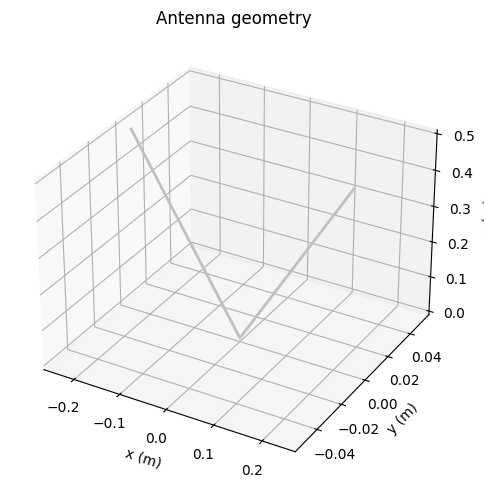

In [7]:
# Antenna geometry
fig = plt.figure(figsize=(6.5, 5.0))
ax = fig.add_subplot(111, projection="3d")
plot_antenna_geometry(ax)
ax.set_title("Antenna geometry")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
plt.tight_layout()
fig.savefig(result_path("antenna_geometry.png"), dpi=160)


### Internal fields (dipole model)

We visualize the toy internal fields inside the conductor to verify near-field
structure. This is a stand-in for full conductor physics and is intended for
qualitative diagnostics.


In [8]:
# Internal field diagnostics (dipole only)
if np.any(inside_mask):
    # Axial profile along the dipole (centerline)
    z_line = np.linspace(-ANTENNA_LENGTH / 2.0, ANTENNA_LENGTH / 2.0, 400)
    I_line = antenna.current_distribution(z_line)
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.5))
    ax.plot(z_line, np.real(I_line), label="Re{I(z)}")
    ax.plot(z_line, np.imag(I_line), label="Im{I(z)}", linestyle="--")
    ax.set_title("Dipole current distribution")
    ax.set_xlabel("z (m)")
    ax.set_ylabel("Current (A)")
    ax.legend(loc="upper right")
    plt.tight_layout()
    fig.savefig(result_path("dipole_current_distribution.png"), dpi=160)
else:
    print("No internal field model for this antenna shape.")


No internal field model for this antenna shape.


### Internal field animation

The internal phasor fields are animated with $\Re\{\mathbf{E} e^{j\omega t}\}$ to
show time-varying structure inside the conductor.


In [9]:
# Internal field animation (dipole model)
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

if not np.any(inside_mask):
    print("Inside mask is empty for this antenna shape; skipping internal-only animation.")
else:
    planes = ["x", "y", "z"]
    plane_titles = {"x": "y-z plane (x=0)", "y": "x-z plane (y=0)", "z": "x-y plane (z=0)"}
    slice_indices = {"x": NX // 2, "y": NY // 2, "z": NZ // 2}

    times = np.linspace(0.0, T_MAX, N_FRAMES)
    phase = np.exp(1j * 2.0 * np.pi * FREQUENCY * times)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Internal E-field magnitude (animated)")

    ims = []
    quivers = []

    for col, axis in enumerate(tqdm(planes, desc="Preparing internal slices")):
        idx = slice_indices[axis]
        xs, ys, uE, vE, xlabel, ylabel = _slice_components(axis, iEx, iEy, iEz, idx)
        inside_slice = {
            "x": inside_mask[NX // 2, :, :],
            "y": inside_mask[:, NY // 2, :],
            "z": inside_mask[:, :, NZ // 2],
        }[axis]

        E0 = np.sqrt(np.real(take_slice(iEx, axis, idx))**2 +
                     np.real(take_slice(iEy, axis, idx))**2 +
                     np.real(take_slice(iEz, axis, idx))**2)
        E0 = np.where(inside_slice, E0, np.nan)

        ax = axes[col]
        norm_e = colors.PowerNorm(gamma=0.4)
        im = ax.pcolormesh(xs, ys, E0, shading="auto", cmap="inferno", norm=norm_e)
        uE_n, vE_n = _normalize_uv(np.real(uE), np.real(vE))
        q = ax.quiver(xs[::QUIVER_STEP, ::QUIVER_STEP], ys[::QUIVER_STEP, ::QUIVER_STEP],
                      uE_n[::QUIVER_STEP, ::QUIVER_STEP], vE_n[::QUIVER_STEP, ::QUIVER_STEP],
                      color="deepskyblue", scale=25)
        ax.set_title(plane_titles[axis])
        ax.set_xlabel(xlabel)
        ax.set_aspect("equal", "box")
        ax.set_ylabel(ylabel)
        fig.colorbar(im, ax=ax, label="|E| (V/m)")
        ims.append(im)
        quivers.append(q)

    def update_internal(frame):
        ph = phase[frame]
        for col, axis in enumerate(planes):
            idx = slice_indices[axis]
            Ex_t = np.real(take_slice(iEx, axis, idx) * ph)
            Ey_t = np.real(take_slice(iEy, axis, idx) * ph)
            Ez_t = np.real(take_slice(iEz, axis, idx) * ph)
            E_mag = np.sqrt(Ex_t**2 + Ey_t**2 + Ez_t**2)
            inside_slice = {
                "x": inside_mask[NX // 2, :, :],
                "y": inside_mask[:, NY // 2, :],
                "z": inside_mask[:, :, NZ // 2],
            }[axis]
            E_mag = np.where(inside_slice, E_mag, np.nan)
            ims[col].set_array(E_mag.ravel())

            uE_t, vE_t = _slice_uv_from_2d(axis, Ex_t, Ey_t, Ez_t)
            uE_n_t, vE_n_t = _normalize_uv(uE_t, vE_t)
            quivers[col].set_UVC(uE_n_t[::QUIVER_STEP, ::QUIVER_STEP],
                                 vE_n_t[::QUIVER_STEP, ::QUIVER_STEP])
        return ims + quivers

    anim = FuncAnimation(fig, update_internal, frames=N_FRAMES, interval=40, blit=False)


Inside mask is empty for this antenna shape; skipping internal-only animation.


## Part 2: Fields in the surrounding space

This section evaluates the radiated fields in the space around the antenna. It includes
field slices, vector overlays, radiation patterns, and time-domain animations that
visualize propagating electromagnetic waves.


### Interpreting the field visualizations

Color maps show field magnitudes, while quiver arrows indicate instantaneous field
directions. The animations reconstruct time-domain fields from phasors to show wave
propagation without separating vectors from the wavefronts.


## Field slices and Poynting vector

We plot |E| and |H| on a central slice with vector overlays, plus the time-averaged
Poynting vector to show power flow. These are the classic diagnostic views for
separating electric and magnetic field structure on 2D planes.


### Field slices on three orthogonal planes

We display $|\mathbf{E}|$, $|\mathbf{H}|$, and the time-averaged Poynting vector
$\mathbf{S} = 	frac{1}{2}\Re\{\mathbf{E}	imes\mathbf{H}^*\}$ on the $x=0$, $y=0$,
and $z=0$ planes. Interior points are masked so only space fields are shown.


Plotting E/H slices:   0%|          | 0/3 [00:00<?, ?it/s]

Plotting E/H slices: 100%|██████████| 3/3 [00:00<00:00, 24.09it/s]

Plotting E/H slices: 100%|██████████| 3/3 [00:00<00:00, 23.97it/s]

Plotting Poynting slices:   0%|          | 0/3 [00:00<?, ?it/s]

Plotting Poynting slices: 100%|██████████| 3/3 [00:00<00:00, 99.86it/s]

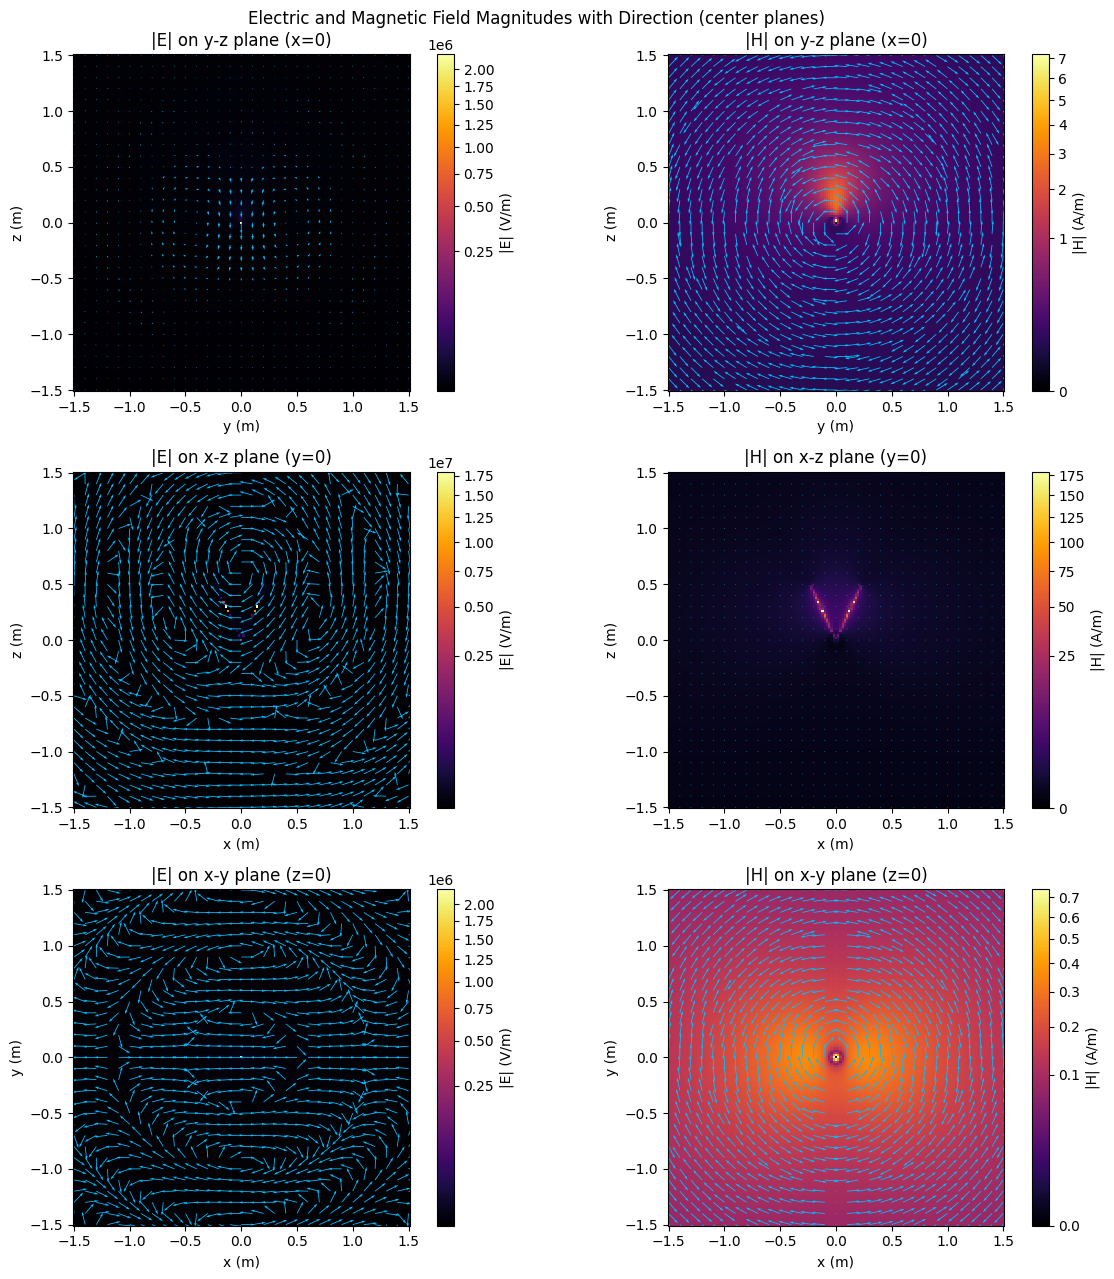

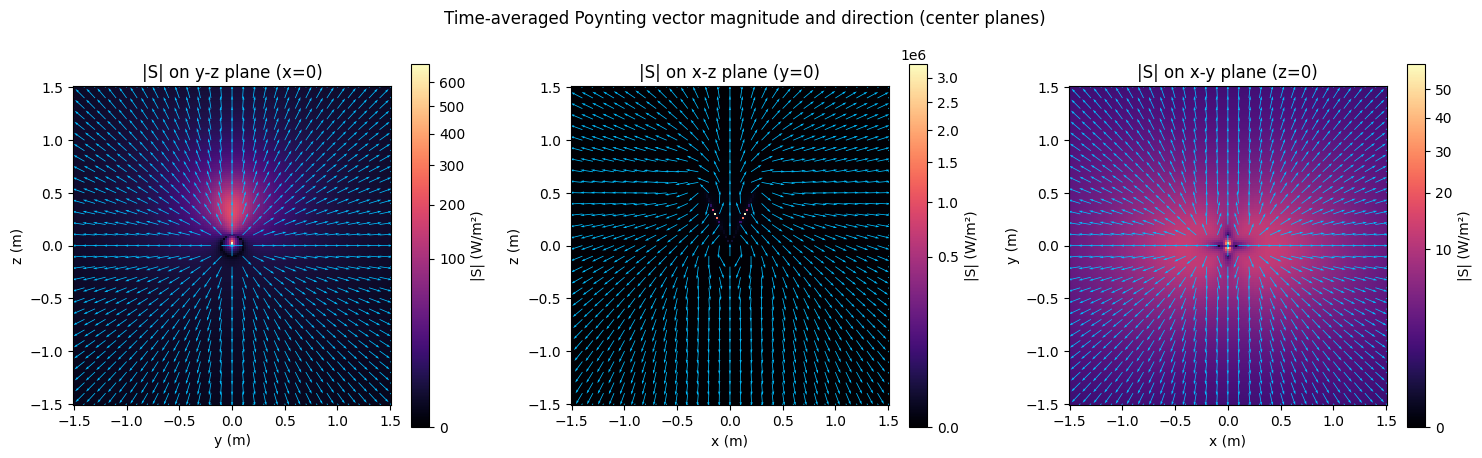

In [10]:
# 2D field slices: E, H, and Poynting vectors on three planes
slice_indices = {
    "x": NX // 2,
    "y": NY // 2,
    "z": NZ // 2,
}

planes = ["x", "y", "z"]
plane_titles = {"x": "y-z plane (x=0)", "y": "x-z plane (y=0)", "z": "x-y plane (z=0)"}


def _slice_components(axis, Fx, Fy, Fz, index):
    if axis == "x":
        xs = Y[index, :, :]
        ys = Z[index, :, :]
        u = Fy[index, :, :]
        v = Fz[index, :, :]
        xlabel, ylabel = "y (m)", "z (m)"
    elif axis == "y":
        xs = X[:, index, :]
        ys = Z[:, index, :]
        u = Fx[:, index, :]
        v = Fz[:, index, :]
        xlabel, ylabel = "x (m)", "z (m)"
    else:
        xs = X[:, :, index]
        ys = Y[:, :, index]
        u = Fx[:, :, index]
        v = Fy[:, :, index]
        xlabel, ylabel = "x (m)", "y (m)"
    return xs, ys, u, v, xlabel, ylabel


def _normalize_uv(u, v):
    mag = np.sqrt(u**2 + v**2) + 1e-12
    return u / mag, v / mag

step = QUIVER_STEP

# Mask interior in space visualizations
inside_slices = {
    "x": inside_mask[NX // 2, :, :],
    "y": inside_mask[:, NY // 2, :],
    "z": inside_mask[:, :, NZ // 2],
}

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
fig.suptitle("Electric and Magnetic Field Magnitudes with Direction (center planes)")

for row, axis in enumerate(tqdm(planes, desc="Plotting E/H slices")):
    idx = slice_indices[axis]
    xs, ys, uE, vE, xlabel, ylabel = _slice_components(axis, Ex, Ey, Ez, idx)
    xs_h, ys_h, uH, vH, _, _ = _slice_components(axis, Hx, Hy, Hz, idx)

    E_mag_s = field_magnitude(
        take_slice(Ex, axis, idx),
        take_slice(Ey, axis, idx),
        take_slice(Ez, axis, idx),
    )
    H_mag_s = field_magnitude(
        take_slice(Hx, axis, idx),
        take_slice(Hy, axis, idx),
        take_slice(Hz, axis, idx),
    )

    if np.any(inside_mask):
        E_mag_s = np.where(inside_slices[axis], np.nan, E_mag_s)
        H_mag_s = np.where(inside_slices[axis], np.nan, H_mag_s)

    uE_n, vE_n = _normalize_uv(np.real(uE), np.real(vE))
    uH_n, vH_n = _normalize_uv(np.real(uH), np.real(vH))

    axE = axes[row, 0]
    norm_e = colors.PowerNorm(gamma=0.4)
    im0 = axE.pcolormesh(xs, ys, np.abs(E_mag_s), shading="auto", cmap="inferno", norm=norm_e)
    axE.quiver(xs[::step, ::step], ys[::step, ::step],
               uE_n[::step, ::step], vE_n[::step, ::step],
               color="deepskyblue", scale=25, label="E direction")
    axE.set_title(f"|E| on {plane_titles[axis]}")
    axE.set_xlabel(xlabel)
    axE.set_aspect("equal", "box")
    axE.set_ylabel(ylabel)
    fig.colorbar(im0, ax=axE, label="|E| (V/m)")

    axH = axes[row, 1]
    norm_h = colors.PowerNorm(gamma=0.4)
    im1 = axH.pcolormesh(xs_h, ys_h, np.abs(H_mag_s), shading="auto", cmap="inferno", norm=norm_h)
    axH.quiver(xs_h[::step, ::step], ys_h[::step, ::step],
               uH_n[::step, ::step], vH_n[::step, ::step],
               color="deepskyblue", scale=25, label="H direction")
    axH.set_title(f"|H| on {plane_titles[axis]}")
    axH.set_xlabel(xlabel)
    axH.set_aspect("equal", "box")
    axH.set_ylabel(ylabel)
    fig.colorbar(im1, ax=axH, label="|H| (A/m)")

plt.tight_layout()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Time-averaged Poynting vector magnitude and direction (center planes)")

for col, axis in enumerate(tqdm(planes, desc="Plotting Poynting slices")):
    idx = slice_indices[axis]
    xs_s, ys_s, uS, vS, xlabel, ylabel = _slice_components(axis, Sx, Sy, Sz, idx)
    uS_n, vS_n = _normalize_uv(uS, vS)
    Smag = np.sqrt(uS**2 + vS**2)
    if np.any(inside_mask):
        Smag = np.where(inside_slices[axis], np.nan, Smag)

    ax = axes[col]
    norm_s = colors.PowerNorm(gamma=0.4)
    im2 = ax.pcolormesh(xs_s, ys_s, Smag, shading="auto", cmap="magma", norm=norm_s)
    ax.quiver(xs_s[::step, ::step], ys_s[::step, ::step],
              uS_n[::step, ::step], vS_n[::step, ::step],
              color="deepskyblue", scale=25, label="S direction")
    ax.set_title(f"|S| on {plane_titles[axis]}")
    ax.set_xlabel(xlabel)
    ax.set_aspect("equal", "box")
    ax.set_ylabel(ylabel)
    fig.colorbar(im2, ax=ax, label="|S| (W/m²)")

plt.tight_layout()


### Animated field slices (three planes)

We reconstruct time-domain slices via $\Re\{\mathbf{E} e^{j\omega t}\}$ and
$\Re\{\mathbf{H} e^{j\omega t}\}$ to visualize propagation across three planes.


Animating 2D slices:   0%|          | 0/3 [00:00<?, ?it/s]

Saving E slice y-z plane (x=0):   0%|          | 0/30 [00:00<?, ?it/s]

Saving E slice y-z plane (x=0):  10%|█         | 3/30 [00:00<00:01, 24.67it/s]

Saving E slice y-z plane (x=0):  20%|██        | 6/30 [00:00<00:01, 23.35it/s]

Saving E slice y-z plane (x=0):  30%|███       | 9/30 [00:00<00:00, 23.02it/s]

...

Saving H slice x-y plane (z=0):  90%|█████████ | 27/30 [00:01<00:00, 19.27it/s]

Saving H slice x-y plane (z=0): 100%|██████████| 30/30 [00:01<00:00, 19.51it/s]

Saving H slice x-y plane (z=0): 100%|██████████| 30/30 [00:02<00:00, 11.77it/s]


Animating 2D slices: 100%|██████████| 3/3 [00:14<00:00,  4.90s/it]

Animating 2D slices: 100%|██████████| 3/3 [00:14<00:00,  4.75s/it]

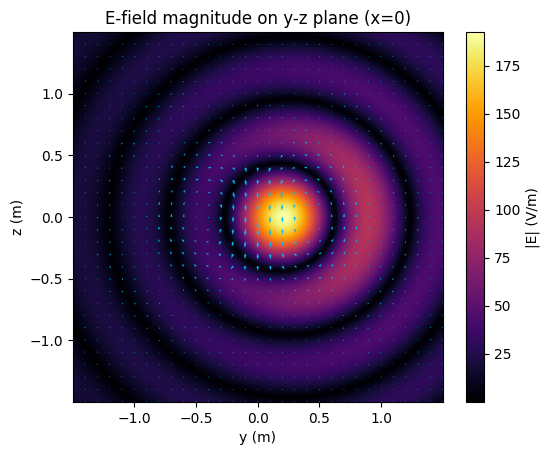

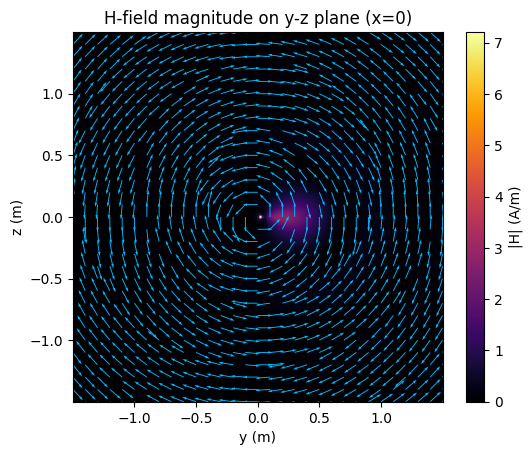

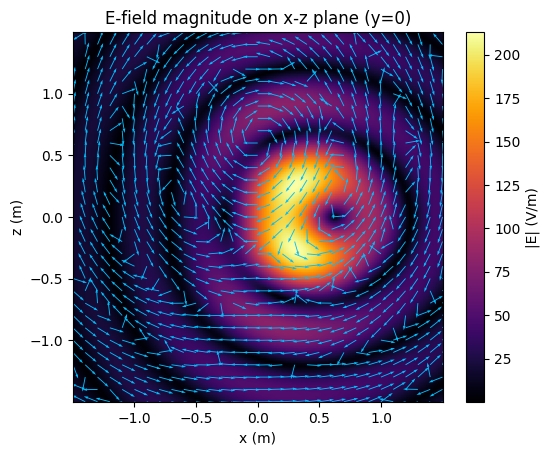

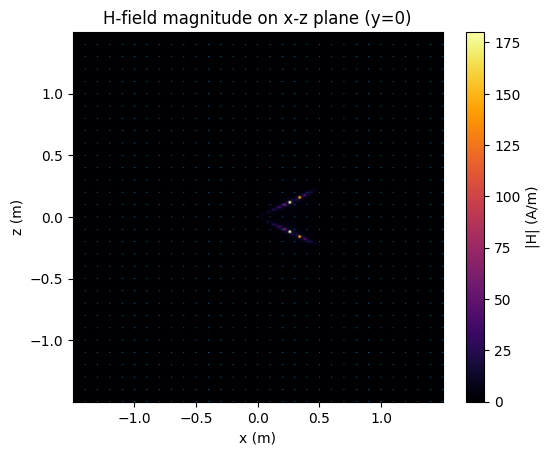

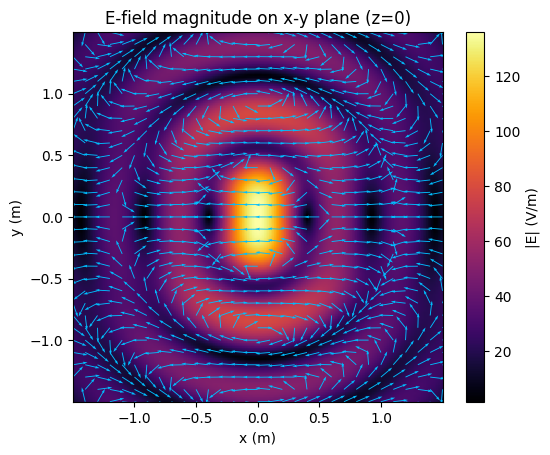

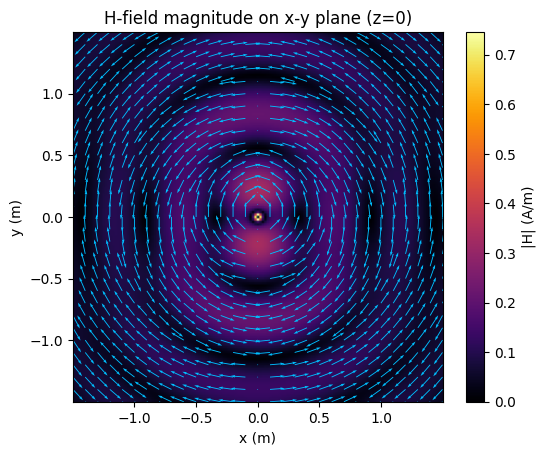

In [11]:
# 2D animations: E and H on three planes
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

planes = ["x", "y", "z"]
plane_titles = {"x": "y-z plane (x=0)", "y": "x-z plane (y=0)", "z": "x-y plane (z=0)"}

slice_indices = {
    "x": NX // 2,
    "y": NY // 2,
    "z": NZ // 2,
}

def _slice_uv_from_2d(axis, Fx_s, Fy_s, Fz_s):
    if axis == "x":
        return Fy_s, Fz_s
    if axis == "y":
        return Fx_s, Fz_s
    return Fx_s, Fy_s


def _extent(xs_grid, ys_grid):
    return [xs_grid.min(), xs_grid.max(), ys_grid.min(), ys_grid.max()]

step = QUIVER_STEP

times = np.linspace(0.0, T_MAX, N_FRAMES)
phase = np.exp(1j * 2.0 * np.pi * FREQUENCY * times)

for axis in tqdm(planes, desc="Animating 2D slices"):
    idx = slice_indices[axis]
    xs, ys, uE, vE, xlabel, ylabel = _slice_components(axis, Ex, Ey, Ez, idx)
    xs_h, ys_h, uH, vH, _, _ = _slice_components(axis, Hx, Hy, Hz, idx)

    Ex_s = take_slice(Ex, axis, idx)
    Ey_s = take_slice(Ey, axis, idx)
    Ez_s = take_slice(Ez, axis, idx)
    Hx_s = take_slice(Hx, axis, idx)
    Hy_s = take_slice(Hy, axis, idx)
    Hz_s = take_slice(Hz, axis, idx)

    fig_e, ax_e = plt.subplots(1, 1, figsize=(6, 4.8))
    E_mag0 = np.sqrt(np.real(Ex_s)**2 + np.real(Ey_s)**2 + np.real(Ez_s)**2)
    im_e = ax_e.imshow(E_mag0, extent=_extent(xs, ys), origin="lower", cmap="inferno")
    uE_n, vE_n = _normalize_uv(np.real(uE), np.real(vE))
    q_e = ax_e.quiver(xs[::step, ::step], ys[::step, ::step],
                      uE_n[::step, ::step], vE_n[::step, ::step],
                      color="deepskyblue", scale=25)
    ax_e.set_title(f"E-field magnitude on {plane_titles[axis]}")
    ax_e.set_xlabel(xlabel)
    ax_e.set_aspect("equal", "box")
    ax_e.set_ylabel(ylabel)
    fig_e.colorbar(im_e, ax=ax_e, label="|E| (V/m)")

    def update_e(frame):
        ph = phase[frame]
        Ex_t = np.real(Ex_s * ph)
        Ey_t = np.real(Ey_s * ph)
        Ez_t = np.real(Ez_s * ph)
        E_mag_t = np.sqrt(Ex_t**2 + Ey_t**2 + Ez_t**2)
        im_e.set_data(E_mag_t)
        uE_t, vE_t = _slice_uv_from_2d(axis, Ex_t, Ey_t, Ez_t)
        uE_n_t, vE_n_t = _normalize_uv(uE_t, vE_t)
        q_e.set_UVC(uE_n_t[::step, ::step], vE_n_t[::step, ::step])
        return im_e, q_e

    anim_e = FuncAnimation(fig_e, update_e, frames=N_FRAMES, interval=40, blit=False)
    save_animation_with_progress(
        anim_e,
        result_path(f"E_slice_{plane_titles[axis].replace(' ', '_')}.gif"),
        fps=18,
        desc=f"Saving E slice {plane_titles[axis]}",
    )

    fig_h, ax_h = plt.subplots(1, 1, figsize=(6, 4.8))
    H_mag0 = np.sqrt(np.real(Hx_s)**2 + np.real(Hy_s)**2 + np.real(Hz_s)**2)
    im_h = ax_h.imshow(H_mag0, extent=_extent(xs_h, ys_h), origin="lower", cmap="inferno")
    uH_n, vH_n = _normalize_uv(np.real(uH), np.real(vH))
    q_h = ax_h.quiver(xs_h[::step, ::step], ys_h[::step, ::step],
                      uH_n[::step, ::step], vH_n[::step, ::step],
                      color="deepskyblue", scale=25)
    ax_h.set_title(f"H-field magnitude on {plane_titles[axis]}")
    ax_h.set_xlabel(xlabel)
    ax_h.set_aspect("equal", "box")
    ax_h.set_ylabel(ylabel)
    fig_h.colorbar(im_h, ax=ax_h, label="|H| (A/m)")

    def update_h(frame):
        ph = phase[frame]
        Hx_t = np.real(Hx_s * ph)
        Hy_t = np.real(Hy_s * ph)
        Hz_t = np.real(Hz_s * ph)
        H_mag_t = np.sqrt(Hx_t**2 + Hy_t**2 + Hz_t**2)
        im_h.set_data(H_mag_t)
        uH_t, vH_t = _slice_uv_from_2d(axis, Hx_t, Hy_t, Hz_t)
        uH_n_t, vH_n_t = _normalize_uv(uH_t, vH_t)
        q_h.set_UVC(uH_n_t[::step, ::step], vH_n_t[::step, ::step])
        return im_h, q_h

    anim_h = FuncAnimation(fig_h, update_h, frames=N_FRAMES, interval=40, blit=False)
    save_animation_with_progress(
        anim_h,
        result_path(f"H_slice_{plane_titles[axis].replace(' ', '_')}.gif"),
        fps=18,
        desc=f"Saving H slice {plane_titles[axis]}",
    )


### Wavefront snapshots

We show the instantaneous real part and the phase of a dominant field component
to make wavefront curvature and phase progression explicit.


Rendering wavefront snapshot:   0%|          | 0/3 [00:00<?, ?it/s]

Rendering wavefront snapshot: 100%|██████████| 3/3 [00:00<00:00, 66.69it/s]

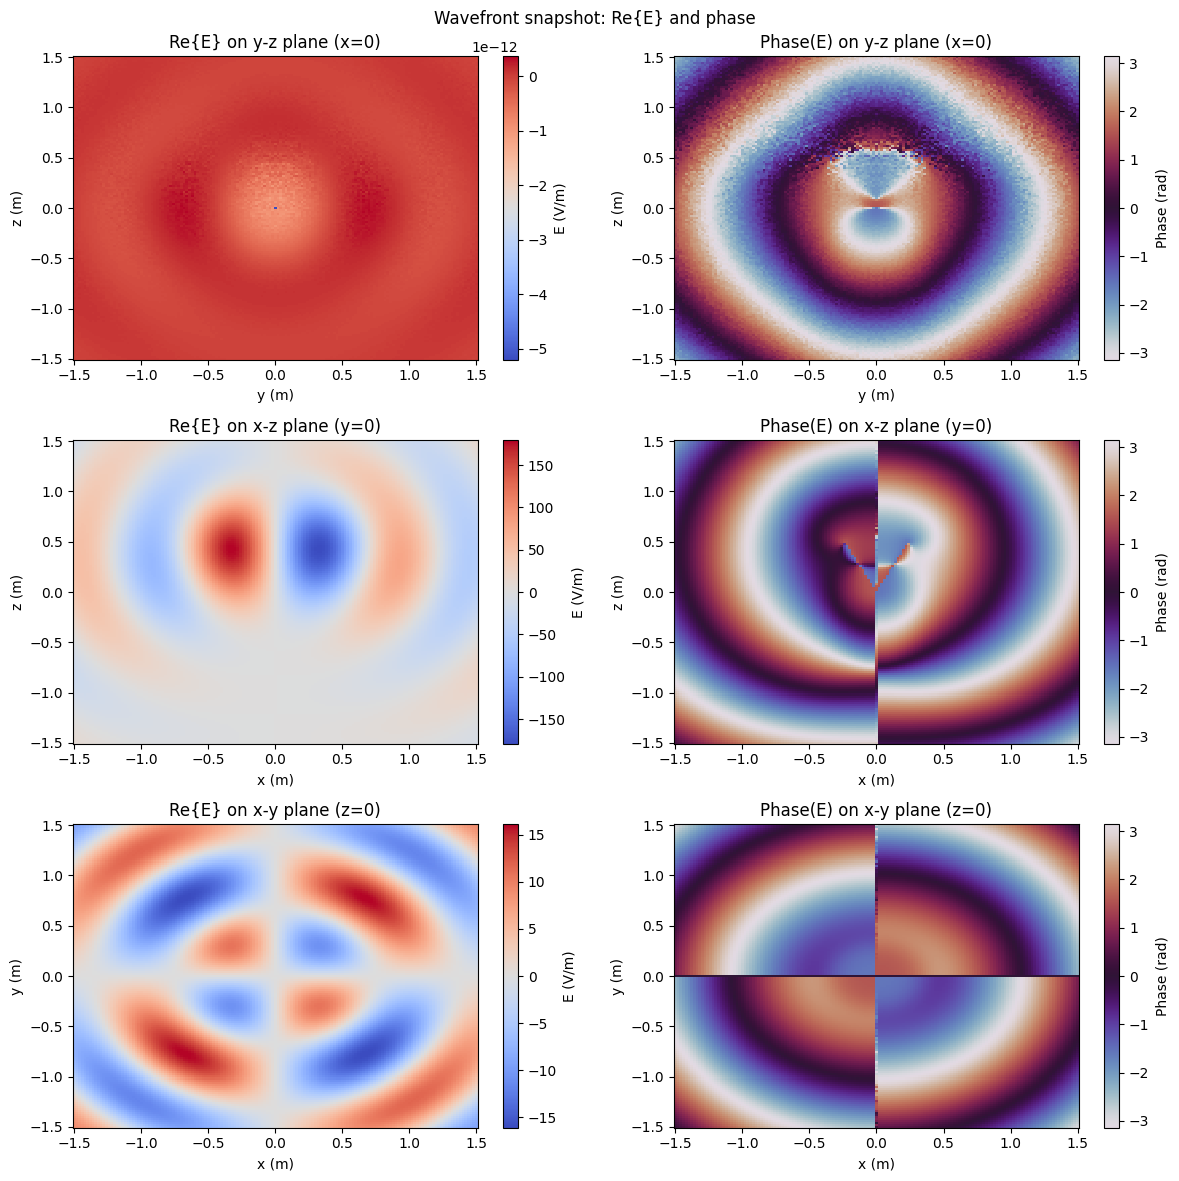

In [12]:
# Wavefront snapshot: real(E) and phase on three planes
planes = ["x", "y", "z"]
plane_titles = {"x": "y-z plane (x=0)", "y": "x-z plane (y=0)", "z": "x-y plane (z=0)"}

slice_indices = {"x": NX // 2, "y": NY // 2, "z": NZ // 2}

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("Wavefront snapshot: Re{E} and phase")

for row, axis in enumerate(tqdm(planes, desc="Rendering wavefront snapshot")):
    idx = slice_indices[axis]
    xs, ys, _, _, xlabel, ylabel = _slice_components(axis, Ex, Ey, Ez, idx)
    Ex_s = take_slice(Ex, axis, idx)
    Ey_s = take_slice(Ey, axis, idx)
    Ez_s = take_slice(Ez, axis, idx)

    if axis == "x":
        E_comp = Ez_s
    elif axis == "y":
        E_comp = Ez_s
    else:
        E_comp = Ey_s

    E_real = np.real(E_comp)
    E_phase = np.angle(E_comp)

    ax0 = axes[row, 0]
    im0 = ax0.pcolormesh(xs, ys, E_real, shading="auto", cmap="coolwarm")
    ax0.set_title(f"Re{{E}} on {plane_titles[axis]}")
    ax0.set_xlabel(xlabel)
    ax0.set_ylabel(ylabel)
    fig.colorbar(im0, ax=ax0, label="E (V/m)")

    ax1 = axes[row, 1]
    im1 = ax1.pcolormesh(xs, ys, E_phase, shading="auto", cmap="twilight")
    ax1.set_title(f"Phase(E) on {plane_titles[axis]}")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    fig.colorbar(im1, ax=ax1, label="Phase (rad)")

plt.tight_layout()


### Wavefront animation

We animate the real part and phase of the dominant field component on each
orthogonal plane to visualize phase progression and wavefront motion.


In [13]:
# Wavefront animation: real(E) and phase per plane
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

planes = ["x", "y", "z"]
plane_titles = {"x": "y-z plane (x=0)", "y": "x-z plane (y=0)", "z": "x-y plane (z=0)"}
slice_indices = {"x": NX // 2, "y": NY // 2, "z": NZ // 2}

times = np.linspace(0.0, T_MAX, N_FRAMES)
phase = np.exp(1j * 2.0 * np.pi * FREQUENCY * times)

for axis in tqdm(planes, desc="Animating wavefronts"):
    idx = slice_indices[axis]
    xs, ys, _, _, xlabel, ylabel = _slice_components(axis, Ex, Ey, Ez, idx)
    Ex_s = take_slice(Ex, axis, idx)
    Ey_s = take_slice(Ey, axis, idx)
    Ez_s = take_slice(Ez, axis, idx)
    if axis == "x":
        E_comp = Ez_s
    elif axis == "y":
        E_comp = Ez_s
    else:
        E_comp = Ey_s

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Wavefront animation: {plane_titles[axis]}")

    E_real = np.real(E_comp)
    E_phase = np.angle(E_comp)

    ax0 = axes[0]
    im0 = ax0.pcolormesh(xs, ys, E_real, shading="auto", cmap="coolwarm")
    ax0.set_title("Re{E}")
    ax0.set_xlabel(xlabel)
    ax0.set_ylabel(ylabel)
    fig.colorbar(im0, ax=ax0, label="E (V/m)")

    ax1 = axes[1]
    im1 = ax1.pcolormesh(xs, ys, E_phase, shading="auto", cmap="twilight")
    ax1.set_title("Phase(E)")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    fig.colorbar(im1, ax=ax1, label="Phase (rad)")

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)

    def update_wave(frame):
        ph = phase[frame]
        im0.set_array(np.real(E_comp * ph).ravel())
        im1.set_array(np.angle(E_comp * ph).ravel())
        return im0, im1

    anim = FuncAnimation(fig, update_wave, frames=N_FRAMES, interval=40, blit=False)
    save_animation_with_progress(
        anim,
        result_path(f"wavefront_animation_{axis}.gif"),
        fps=18,
        desc=f"Saving wavefront animation {axis}",
    )
    fig.savefig(result_path(f"wavefront_snapshot_{axis}.png"), dpi=160)
    plt.close(fig)


Animating wavefronts:   0%|          | 0/3 [00:00<?, ?it/s]

Saving wavefront animation x:   0%|          | 0/30 [00:00<?, ?it/s]

Saving wavefront animation x:   7%|▋         | 2/30 [00:00<00:02, 13.86it/s]

Saving wavefront animation x:  13%|█▎        | 4/30 [00:00<00:02, 11.13it/s]

Saving wavefront animation x:  20%|██        | 6/30 [00:00<00:02, 10.28it/s]

...

Saving wavefront animation z:  97%|█████████▋| 29/30 [00:03<00:00,  8.63it/s]

Saving wavefront animation z: 100%|██████████| 30/30 [00:03<00:00,  8.67it/s]

Saving wavefront animation z: 100%|██████████| 30/30 [00:04<00:00,  6.99it/s]


Animating wavefronts: 100%|██████████| 3/3 [00:13<00:00,  4.60s/it]

Animating wavefronts: 100%|██████████| 3/3 [00:13<00:00,  4.63s/it]

## 3D field vectors and antenna geometry

A sparse 3D quiver view of the electric field with a cylinder showing the antenna body.

### 3D field overview

A sparse 3D view combines a high-intensity isosurface (via point thresholding)
with instantaneous field vectors. Color encodes $\log_{10}|\mathbf{E}|$.


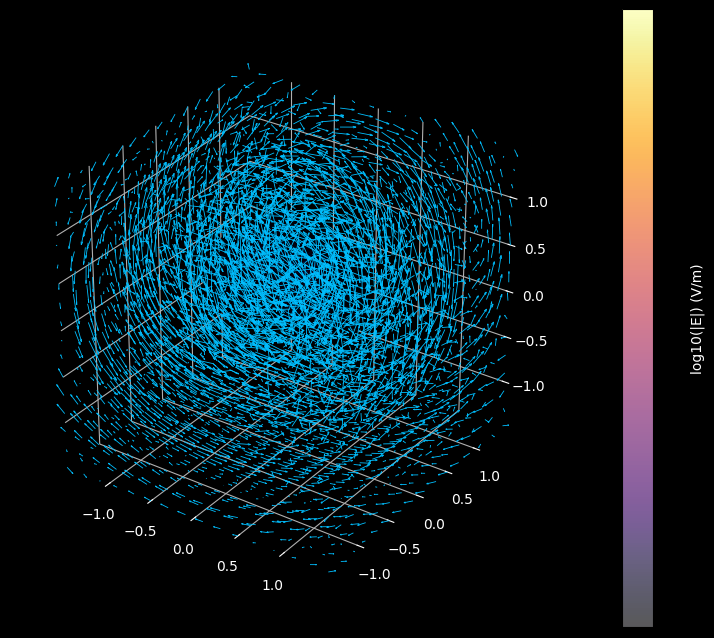

In [14]:
# 3D visualization: field intensity + vectors (styled)
fig = plt.figure(figsize=(7.5, 6.5), facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black')

stride = 3
Xs = X[::stride, ::stride, ::stride]
Ys = Y[::stride, ::stride, ::stride]
Zs = Z[::stride, ::stride, ::stride]
Em = E_mag[::stride, ::stride, ::stride]

threshold = np.nanpercentile(Em, 96)
mask = Em > threshold

colors = np.log10(Em[mask] + 1e-12)
sc = ax.scatter(Xs[mask], Ys[mask], Zs[mask], c=colors,
                cmap='inferno', s=6, alpha=0.65)

# Sparse field vectors
qs = QUIVER_STEP * 2
xs = X[::qs, ::qs, ::qs]
ys = Y[::qs, ::qs, ::qs]
zs = Z[::qs, ::qs, ::qs]
exs = Ex[::qs, ::qs, ::qs].real
eys = Ey[::qs, ::qs, ::qs].real
ezs = Ez[::qs, ::qs, ::qs].real
exs_n, eys_n, ezs_n = _scale_vec3(exs, eys, ezs)

ax.quiver(xs, ys, zs, exs_n, eys_n, ezs_n, length=QUIVER_3D_LENGTH, normalize=False,
          color='deepskyblue', linewidth=0.6, arrow_length_ratio=0.2)

# Antenna geometry
plot_antenna_geometry(ax)

ax.view_init(elev=CAMERA_ELEV, azim=CAMERA_AZIM)
try:
    ax.dist = CAMERA_DIST
except Exception:
    pass

ax.set_title('3D field intensity + vectors')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
ax.tick_params(colors='white')
_set_3d_axes(ax, (-EXTENT_M, EXTENT_M), (-EXTENT_M, EXTENT_M), (-EXTENT_M, EXTENT_M))
ax.xaxis.set_pane_color((0, 0, 0, 1))
ax.yaxis.set_pane_color((0, 0, 0, 1))
ax.zaxis.set_pane_color((0, 0, 0, 1))

cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('log10(|E|) (V/m)', color='white')
plt.tight_layout()
fig.savefig(result_path("field_3d_overview.png"), dpi=160)


## Radiation pattern (far field)

We sample the field on a sphere in the x-z plane and plot the angular radiation pattern.

### Far-field radiation pattern

The far-field is evaluated on a large-radius circle in the $x$–$z$ plane to
compute the normalized radiation pattern $|E(	heta)| / \max |E|$.


Wire segments:   0%|          | 0/360 [00:00<?, ?it/s]

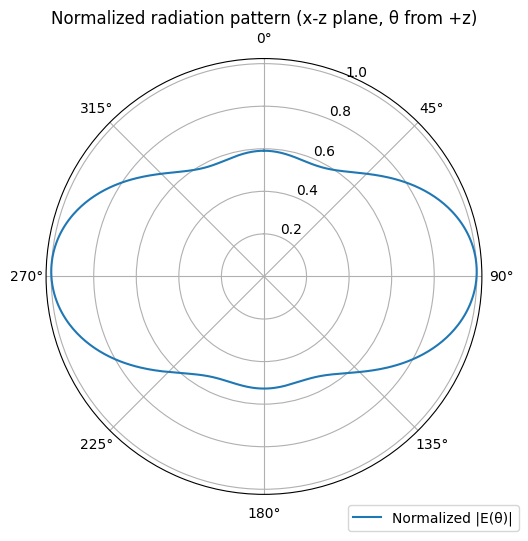

In [15]:
# Far-field sampling in x-z plane
theta = np.linspace(0.0, 2.0 * np.pi, 721)  # full circle in the x-z plane, from +z
r_far = 10.0 * (C0 / FREQUENCY)
x_far = r_far * np.sin(theta)
y_far = np.zeros_like(theta)
z_far = r_far * np.cos(theta)

if ANTENNA_TYPE == "dipole":
    if MODEL == "line":
        E_far = line_dipole_fields(antenna, x_far, y_far, z_far, n_segments=N_SEGMENTS)
    else:
        E_far = dipole_fields(antenna, x_far, y_far, z_far)
else:
    E_far = wire_antenna_fields(antenna, x_far, y_far, z_far)

E_far_mag = field_magnitude(E_far[0], E_far[1], E_far[2])
E_far_norm = E_far_mag / np.max(E_far_mag)

fig = plt.figure(figsize=(5.5, 5.5))
ax = fig.add_subplot(111, projection='polar')
ax.plot(theta, E_far_norm, label='Normalized |E(θ)|')
ax.set_theta_zero_location('N')  # +z up
ax.set_theta_direction(-1)  # +x to the right
ax.set_title('Normalized radiation pattern (x-z plane, θ from +z)')
ax.legend(loc='lower right', bbox_to_anchor=(1.1, -0.1))
plt.tight_layout()
fig.savefig(result_path("far_field_pattern_xz.png"), dpi=160)


## Time animation (propagating wave)

We reconstruct time-domain fields from phasors on a slice, then animate the
propagating wave. These animations keep the vector fields co-located with
the wavefronts instead of separating them into different views.


### 3D space-field animation

The radiated field is animated in space with the antenna interior excluded so
the wavefronts are not obscured by conductor fields.


In [16]:
# 3D animation: radiated waves in space (excluding antenna interior)
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

times = np.linspace(0.0, T_MAX, N_FRAMES)
phase = np.exp(1j * 2.0 * np.pi * FREQUENCY * times)

stride = 5
qs = 8
gamma_3d = 0.28
eps = 1e-12

Xs = X[::stride, ::stride, ::stride]
Ys = Y[::stride, ::stride, ::stride]
Zs = Z[::stride, ::stride, ::stride]
inside_s = inside_mask[::stride, ::stride, ::stride]

xs = X[::qs, ::qs, ::qs]
ys = Y[::qs, ::qs, ::qs]
zs = Z[::qs, ::qs, ::qs]
inside_q = inside_mask[::qs, ::qs, ::qs]

exs_base = Ex[::qs, ::qs, ::qs]
eys_base = Ey[::qs, ::qs, ::qs]
ezs_base = Ez[::qs, ::qs, ::qs]
mag_base = np.sqrt(np.abs(exs_base)**2 + np.abs(eys_base)**2 + np.abs(ezs_base)**2)
if np.any(~inside_q):
    mag_base = mag_base[~inside_q]
vec_scale = np.nanpercentile(mag_base, 95)
if not np.isfinite(vec_scale) or vec_scale <= 0:
    vec_scale = 1.0

AX_LIM = EXTENT_M

fig = plt.figure(figsize=(7.2, 6.0), facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black')

def update_space(frame):
    ax.cla()
    ph = phase[frame]
    Ex_t = np.real(Ex * ph)
    Ey_t = np.real(Ey * ph)
    Ez_t = np.real(Ez * ph)
    Em = np.sqrt(Ex_t**2 + Ey_t**2 + Ez_t**2)
    Em = np.abs(Em) ** gamma_3d
    Em_s = Em[::stride, ::stride, ::stride]
    if np.any(~inside_s):
        mask = (~inside_s) & (Em_s > np.percentile(Em_s[~inside_s], 97))
    else:
        mask = Em_s > np.percentile(Em_s, 97)

    ax.scatter(Xs[mask], Ys[mask], Zs[mask], c=np.log10(Em_s[mask] + eps),
               cmap='inferno', s=6, alpha=0.8)

    exs_t = np.real(exs_base * ph)
    eys_t = np.real(eys_base * ph)
    ezs_t = np.real(ezs_base * ph)
    exs_n, eys_n, ezs_n = _apply_vec_scale(exs_t, eys_t, ezs_t, vec_scale, max_norm=1.0)
    ax.quiver(xs[~inside_q], ys[~inside_q], zs[~inside_q],
              exs_n[~inside_q], eys_n[~inside_q], ezs_n[~inside_q],
              length=QUIVER_3D_LENGTH, normalize=False,
              color='deepskyblue', linewidth=0.6, arrow_length_ratio=0.2)

    plot_antenna_geometry(ax)

    ax.view_init(elev=CAMERA_ELEV, azim=CAMERA_AZIM)
    try:
        ax.dist = CAMERA_DIST
    except Exception:
        pass
    ax.set_title('3D radiated fields (animated)', color='white')
    ax.set_xlabel('x (m)', color='white')
    ax.set_ylabel('y (m)', color='white')
    ax.set_zlabel('z (m)', color='white')
    ax.tick_params(colors='white')
    _set_3d_axes(ax, (-AX_LIM, AX_LIM), (-AX_LIM, AX_LIM), (-AX_LIM, AX_LIM))
    ax.xaxis.set_pane_color((0, 0, 0, 1))
    ax.yaxis.set_pane_color((0,  0, 0, 1))
    ax.zaxis.set_pane_color((0, 0, 0, 1))

anim = FuncAnimation(fig, update_space, frames=N_FRAMES, interval=40)
plt.close(fig)
save_animation_with_progress(
    anim,
    result_path("space_field_3d_radiated.gif"),
    fps=18,
    desc="Saving 3D radiated animation",
)


Saving 3D radiated animation:   0%|          | 0/30 [00:00<?, ?it/s]

Saving 3D radiated animation:   3%|▎         | 1/30 [00:01<00:32,  1.11s/it]

Saving 3D radiated animation:   7%|▋         | 2/30 [00:02<00:43,  1.54s/it]

Saving 3D radiated animation:  10%|█         | 3/30 [00:04<00:42,  1.56s/it]

Saving 3D radiated animation:  13%|█▎        | 4/30 [00:06<00:40,  1.55s/it]

...

Saving 3D radiated animation:  90%|█████████ | 27/30 [00:44<00:05,  1.70s/it]

Saving 3D radiated animation:  93%|█████████▎| 28/30 [00:46<00:03,  1.70s/it]

Saving 3D radiated animation:  97%|█████████▋| 29/30 [00:48<00:01,  1.69s/it]

Saving 3D radiated animation: 100%|██████████| 30/30 [00:49<00:00,  1.70s/it]

Saving 3D radiated animation: 100%|██████████| 30/30 [00:51<00:00,  1.72s/it]

### 3D field animation (space)

A time-domain animation of $\Re\{\mathbf{E} e^{j\omega t}\}$ shows the evolution
of field intensity and direction in space.


In [17]:
# 3D animation: magnetic field intensity + vectors
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

stride = 5
qs = 8
gamma_3d = 0.28
eps = 1e-12

times = np.linspace(0.0, T_MAX, N_FRAMES)

Xs = X[::stride, ::stride, ::stride]
Ys = Y[::stride, ::stride, ::stride]
Zs = Z[::stride, ::stride, ::stride]

xs = X[::qs, ::qs, ::qs]
ys = Y[::qs, ::qs, ::qs]
zs = Z[::qs, ::qs, ::qs]

hxs_base = Hx[::qs, ::qs, ::qs]
hys_base = Hy[::qs, ::qs, ::qs]
hzs_base = Hz[::qs, ::qs, ::qs]
mag_base = np.sqrt(np.abs(hxs_base)**2 + np.abs(hys_base)**2 + np.abs(hzs_base)**2)
vec_scale = np.nanpercentile(mag_base, 95)
if not np.isfinite(vec_scale) or vec_scale <= 0:
    vec_scale = 1.0

AX_LIM = EXTENT_M

fig = plt.figure(figsize=(7.2, 6.0), facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black')

def update_3d(frame):
    ax.cla()
    t = times[frame]
    phase = np.exp(1j * 2.0 * np.pi * FREQUENCY * t)

    Hx_t = np.real(Hx * phase)
    Hy_t = np.real(Hy * phase)
    Hz_t = np.real(Hz * phase)
    H_mag_t = np.sqrt(Hx_t**2 + Hy_t**2 + Hz_t**2)
    H_mag_t = np.abs(H_mag_t) ** gamma_3d

    Em = H_mag_t[::stride, ::stride, ::stride]
    thr = np.percentile(Em, 97)
    mask = Em > thr

    ax.scatter(Xs[mask], Ys[mask], Zs[mask], c=np.log10(Em[mask] + eps),
               cmap='inferno', s=6, alpha=0.8)

    hxs_t = np.real(hxs_base * phase)
    hys_t = np.real(hys_base * phase)
    hzs_t = np.real(hzs_base * phase)
    hxs_n, hys_n, hzs_n = _apply_vec_scale(hxs_t, hys_t, hzs_t, vec_scale, max_norm=1.0)
    ax.quiver(xs, ys, zs, hxs_n, hys_n, hzs_n, length=QUIVER_3D_LENGTH, normalize=False,
              color='deepskyblue', linewidth=0.6, arrow_length_ratio=0.2)

    plot_antenna_geometry(ax)

    ax.view_init(elev=CAMERA_ELEV, azim=CAMERA_AZIM)
    try:
        ax.dist = CAMERA_DIST
    except Exception:
        pass
    ax.set_title('3D magnetic field intensity + vectors (animated)', color='white')
    ax.set_xlabel('x (m)', color='white')
    ax.set_ylabel('y (m)', color='white')
    ax.set_zlabel('z (m)', color='white')
    ax.tick_params(colors='white')
    _set_3d_axes(ax, (-AX_LIM, AX_LIM), (-AX_LIM, AX_LIM), (-AX_LIM, AX_LIM))
    ax.xaxis.set_pane_color((0, 0, 0, 1))
    ax.yaxis.set_pane_color((0, 0, 0, 1))
    ax.zaxis.set_pane_color((0, 0, 0, 1))

anim = FuncAnimation(fig, update_3d, frames=N_FRAMES, interval=40)
plt.close(fig)
save_animation_with_progress(
    anim,
    result_path("space_field_3d_h_vectors.gif"),
    fps=18,
    desc="Saving 3D magnetic animation",
)


Saving 3D magnetic animation:   0%|          | 0/30 [00:00<?, ?it/s]

Saving 3D magnetic animation:   3%|▎         | 1/30 [00:00<00:27,  1.05it/s]

Saving 3D magnetic animation:   7%|▋         | 2/30 [00:02<00:38,  1.37s/it]

Saving 3D magnetic animation:  10%|█         | 3/30 [00:04<00:41,  1.52s/it]

Saving 3D magnetic animation:  13%|█▎        | 4/30 [00:05<00:40,  1.58s/it]

...

Saving 3D magnetic animation:  90%|█████████ | 27/30 [00:49<00:04,  1.61s/it]

Saving 3D magnetic animation:  93%|█████████▎| 28/30 [00:51<00:03,  1.59s/it]

Saving 3D magnetic animation:  97%|█████████▋| 29/30 [00:52<00:01,  1.58s/it]

Saving 3D magnetic animation: 100%|██████████| 30/30 [00:54<00:00,  1.59s/it]

Saving 3D magnetic animation: 100%|██████████| 30/30 [00:55<00:00,  1.86s/it]

## Notes and extension points

- Replace `current_distribution` in `DipoleAntenna` to model different antenna types.
- Swap `line_dipole_fields` for a full-wave solver if you want conductivity, losses, or materials.
- Increase `N_SEGMENTS` for a smoother near field at the cost of runtime.
- The internal antenna fields are still a lightweight toy model; keep them or replace as needed.